# Network Analysis Tutorial: Centrality Measures & Community Detection

**Learning objectives.** By the end of this notebook you should be able to:

1. Explain *why* we measure centrality and *why* we look for communities in networks.
2. Describe the intuition, mathematics, and original references behind widely used centrality measures and community detection algorithms.
3. Compute each of them in Python with `networkx` and interpret the output.
4. **Compare** methods against each other and against a known ground truth.

| Part | Content |
|---|---|
| 0 | Setup and a quick refresher on graphs |
| 1 | Centrality: Degree, Closeness, Betweenness, Eigenvector, PageRank → comparison |
| 2 | Community detection: Modularity, how to evaluate a partition (NMI & ARI), Greedy modularity, Louvain, Leiden, Label propagation → comparison → linking centrality and communities |
| 3 | Summary, exercises, references |

We use one dataset throughout: **Zachary's Karate Club**, a small social network with a *known* real-world split into two groups. Keeping the same network makes every comparison direct.

---
# Part 0 — Setup and Graph Refresher

## 0.1 Libraries

- **`networkx`**: creating and analyzing graphs (Hagberg, Schult & Swart, 2008).
- **`matplotlib`**, **`pandas`**, **`numpy`**, **`scipy`**: plotting, tables, numerics.
- **`scikit-learn`**: comparing community partitions (NMI, ARI).
- *(optional)* **`python-igraph` + `leidenalg`**: the Leiden algorithm.

In [1]:
# !pip install networkx matplotlib pandas numpy scipy scikit-learn
# !pip install python-igraph leidenalg     # optional, only for the Leiden section

In [2]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from networkx.algorithms import community as nx_comm   # community-detection tools live here
from scipy.stats import spearmanr

SEED = 19880106                                   # several algorithms are randomized: fix the seed
plt.rcParams["figure.figsize"] = (8, 6)

## 0.2 What is a network (graph)?

A **graph** $G = (V, E)$ consists of:
- a set of **nodes** (vertices) $V$, e.g. people;
- a set of **edges** (links) $E$, e.g. friendships between pairs of people.

**Notation: $n = |V|$ and $m = |E|$.** The vertical bars $|\cdot|$ mean *"the number of elements in the set"* (its size, or *cardinality*). So:
- $n = |V|$ is the **number of nodes**,
- $m = |E|$ is the **number of edges**.

For example, if $V = \{A, B, C\}$ and $E = \{(A,B), (B,C)\}$, then $n = 3$ and $m = 2$. We use $n$ and $m$ in almost every formula below, e.g. to normalize scores or to state how fast an algorithm runs.

Other basic terms:
- **Adjacency matrix $A$:** an $n \times n$ table with $A_{ij}=1$ if nodes $i$ and $j$ are connected, and $0$ otherwise.
- **Degree $k_i$:** the number of edges attached to node $i$: $k_i = \sum_j A_{ij}$.
- **Shortest-path distance $d(i,j)$:** the minimum number of edges (steps) needed to go from $i$ to $j$. Neighbours are at distance 1, friends-of-friends at distance 2, and so on.
- **Directed vs. undirected, weighted vs. unweighted:** friendships are undirected (A–B is the same as B–A); edges may also carry weights (e.g. how often two people meet).

## 0.3 Our dataset: Zachary's Karate Club

Zachary (1977) recorded friendships among **34 members** of a university karate club ($n = 34$, $m = 78$). A conflict between the instructor ("Mr. Hi", node **0**) and the administrator ("Officer", node **33**) split the club in two. We *know* which side each member joined, so we can check whether algorithms recover the split.

**`nx.karate_club_graph()`** returns the network as an undirected `nx.Graph`. Each node has a `"club"` attribute (`"Mr. Hi"` or `"Officer"`). Edges also carry a `"weight"` attribute, which we ignore here to keep things simple.

In [3]:
G = nx.karate_club_graph()

print("n = |V| (nodes):", G.number_of_nodes())
print("m = |E| (edges):", G.number_of_edges())
print("Connected?     :", nx.is_connected(G))    # can every node reach every other node?
print("Density        :", round(nx.density(G), 3))  # share of all possible edges that exist: m / (n(n-1)/2)

club = nx.get_node_attributes(G, "club")         # {node: "Mr. Hi" or "Officer"}

n = |V| (nodes): 34
m = |E| (edges): 78
Connected?     : True
Density        : 0.139


| Function | What it does | How it works |
|---|---|---|
| `G.number_of_nodes()` / `G.number_of_edges()` | Returns $n$ / $m$ | networkx stores a graph as a dictionary of neighbours; these count its entries. |
| `nx.is_connected(G)` | `True` if every node can reach every other | Breadth-first search (BFS) from one node, then checks that all nodes were visited. |
| `nx.density(G)` | $\frac{m}{n(n-1)/2}$ | Divides $m$ by the number of possible pairs. |
| `nx.get_node_attributes(G, name)` | `{node: value}` for one attribute | Loops over the nodes' stored data. |

We compute node positions **once** and reuse them, so all plots are directly comparable.

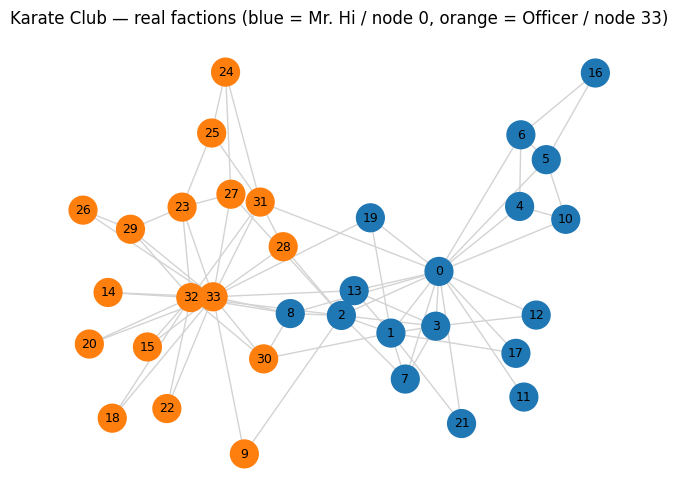

In [4]:
# spring_layout: force-directed layout (Fruchterman & Reingold, 1991).
# Edges act like springs pulling nodes together; all nodes repel each other.
pos = nx.spring_layout(G, seed=SEED)
true_colors = ["tab:blue" if club[v] == "Mr. Hi" else "tab:orange" for v in G]

nx.draw_networkx(G, pos=pos, node_color=true_colors, node_size=400, font_size=9, edge_color="lightgray")
plt.title("Karate Club — real factions (blue = Mr. Hi / node 0, orange = Officer / node 33)")
plt.axis("off")
plt.show()

In [5]:
def draw_scores(G, scores, ax, title, cmap=plt.cm.viridis):
    '''Draw G on axis `ax` with node size and colour proportional to a score dict {node: value}.'''
    v = np.array([scores[n] for n in G])
    sizes = 60 + 900 * (v - v.min()) / (v.max() - v.min() + 1e-12)   # rescale to a readable size range
    nx.draw_networkx_edges(G, pos, edge_color="lightgray", ax=ax)
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=v, cmap=cmap, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
    ax.set_title(title)
    ax.axis("off")

def top_k(scores, k=5):
    '''The k highest-scoring nodes as a list of (node, score).'''
    return sorted(scores.items(), key=lambda item: item[1], reverse=True)[:k]

---
# Part 1 — Centrality Measures

## 1.1 What is centrality?

**Centrality** answers: *"Which nodes are the most important?"* The key insight is that **"important" has no single definition**. A node can be important because it:

| Idea of importance | Measure | How it is measured |
|---|---|---|
| has **many connections** | Degree | count its neighbours |
| is **close to everyone else** | Closeness | average **shortest-path distance** to all other nodes (see below) |
| **sits between** others and can broker flows | Betweenness | share of shortest paths between other pairs that pass through it |
| is **connected to other important nodes** | Eigenvector, PageRank | a node's score is built from its neighbours' scores |

**How do we measure "close to everyone"?** We use the shortest-path distance $d(i,j)$ from Section 0.2: the fewest number of steps from $i$ to $j$. If node $i$ can reach every other node in 1–2 steps, it is "close to everyone"; if it needs 4–5 steps to reach some, it is far away. Closeness centrality (Section 1.3) turns the *average* of these distances into a score.

Each measure encodes an assumption about *how things flow* through the network (information, disease, influence), so the right measure depends on your research question (Borgatti, 2005).

**Key references:** Freeman, L. C. (1978). Centrality in social networks: Conceptual clarification. *Social Networks*, 1(3), 215–239. · Borgatti, S. P. (2005). Centrality and network flow. *Social Networks*, 27(1), 55–71.

## 1.2 Degree Centrality

A node is important if it has many direct connections:

$$C_D(i) = \frac{k_i}{n-1}$$

Dividing by $n-1$ (the most neighbours a node could have) puts scores in $[0,1]$.
- **Good for:** immediate exposure or popularity ("who has the most friends?").
- **Limitation:** purely *local*; ignores everything beyond direct neighbours.

**Reference:** Freeman (1978), above.

**`nx.degree_centrality(G)`** loops over nodes and returns `{node: degree / (n - 1)}`. `G.degree()` gives the raw counts.

In [6]:
degree_c = nx.degree_centrality(G)
print("Raw degree of nodes 0 and 33:", G.degree(0), G.degree(33))
print("Top-5 by degree:", [(v, round(s, 3)) for v, s in top_k(degree_c)])

Raw degree of nodes 0 and 33: 16 17
Top-5 by degree: [(33, 0.515), (0, 0.485), (32, 0.364), (2, 0.303), (1, 0.273)]


## 1.3 Closeness Centrality

A node is central if its **average shortest-path distance** to all other nodes is small. Closeness is the inverse of that average:

$$C_C(i) = \frac{n-1}{\sum_{j \neq i} d(i,j)}$$

A node that reaches everyone in one step has closeness 1; larger distances give smaller scores.
- **Good for:** how quickly something starting at $i$ can reach the whole network.
- **Limitation:** on disconnected graphs some distances are infinite (networkx then rescales within each component).

**References:** Bavelas, A. (1950). Communication patterns in task-oriented groups. *J. Acoustical Society of America*, 22(6), 725–730. · Sabidussi, G. (1966). The centrality index of a graph. *Psychometrika*, 31(4), 581–603.

**`nx.closeness_centrality(G, distance=None)`**: for each node, runs a BFS (`single_source_shortest_path_length`) to get all distances, sums them, and inverts. `distance` can name an edge attribute to use as edge length. Below we reproduce the calculation for node 0 by hand.

In [7]:
closeness_c = nx.closeness_centrality(G)

# By hand for node 0: get its distance to every node, then apply the formula
dist_from_0 = nx.single_source_shortest_path_length(G, 0)       # {node: number of steps from node 0}
print("How many nodes node 0 reaches in 1, 2, 3 steps:",
      pd.Series(dist_from_0).value_counts().sort_index().drop(0).to_dict())
print(f"Node 0 closeness — by hand: {(len(G) - 1) / sum(dist_from_0.values()):.4f} | networkx: {closeness_c[0]:.4f}")
print("Top-5 by closeness:", [(v, round(s, 3)) for v, s in top_k(closeness_c)])

How many nodes node 0 reaches in 1, 2, 3 steps: {1: 16, 2: 9, 3: 8}
Node 0 closeness — by hand: 0.5690 | networkx: 0.5690
Top-5 by closeness: [(0, 0.569), (2, 0.559), (33, 0.55), (31, 0.541), (8, 0.516)]


## 1.4 Betweenness Centrality

How often does a node lie **on the shortest paths between other pairs**?

$$C_B(i) = \sum_{s \neq i \neq t} \frac{\sigma_{st}(i)}{\sigma_{st}}$$

$\sigma_{st}$ = number of shortest paths from $s$ to $t$; $\sigma_{st}(i)$ = how many of them pass through $i$.
- **Good for:** finding brokers and gatekeepers who connect otherwise separate groups.
- **Computation:** Brandes' algorithm, $O(nm)$: one BFS per node plus a backward pass that accumulates path counts.

**References:** Freeman, L. C. (1977). A set of measures of centrality based on betweenness. *Sociometry*, 40(1), 35–41. · Brandes, U. (2001). A faster algorithm for betweenness centrality. *J. Mathematical Sociology*, 25(2), 163–177.

**`nx.betweenness_centrality(G, k=None, normalized=True, weight=None, seed=None)`**
- `normalized`: scale scores to $[0,1]$.
- `k`: estimate from `k` random source nodes only. This is much faster on large graphs but approximate.
- `weight`: edge attribute to use as distance.

In [8]:
betweenness_c = nx.betweenness_centrality(G)
print("Top-5 by betweenness:", [(v, round(s, 3)) for v, s in top_k(betweenness_c)])
print("Nodes with betweenness ≈ 0 (never needed as intermediaries):",
      sum(s < 0.001 for s in betweenness_c.values()), "of", len(G))

Top-5 by betweenness: [(0, 0.438), (33, 0.304), (32, 0.145), (2, 0.144), (31, 0.138)]
Nodes with betweenness ≈ 0 (never needed as intermediaries): 15 of 34


## 1.5 Eigenvector Centrality

**A node is important if its neighbours are important.** Each node's score is proportional to the sum of its neighbours' scores:

$$x_i = \frac{1}{\lambda}\sum_j A_{ij}\,x_j \quad\Longleftrightarrow\quad A\mathbf{x} = \lambda\mathbf{x}$$

So $\mathbf{x}$ is the leading eigenvector of the adjacency matrix. It is found by **power iteration**: start with all scores equal to 1, repeatedly replace each score by the sum of the neighbours' scores, and rescale, until nothing changes.
- **Limitation:** poorly defined for directed or disconnected graphs; PageRank fixes this.

**References:** Bonacich, P. (1972). Factoring and weighting approaches to status scores and clique identification. *J. Mathematical Sociology*, 2(1), 113–120. · Bonacich, P. (1987). Power and centrality: A family of measures. *American Journal of Sociology*, 92(5), 1170–1182.

**`nx.eigenvector_centrality(G, max_iter=100, tol=1e-06, weight=None)`** runs power iteration; `max_iter` limits the iterations and `tol` sets when to stop. Below we write the same loop ourselves.

In [9]:
eigenvector_c = nx.eigenvector_centrality(G, max_iter=1000)

# Power iteration by hand
A = nx.to_numpy_array(G, weight=None)        # adjacency matrix, rows/columns in G.nodes() order
x = np.ones(len(G))                          # start: everyone has score 1
for it in range(1000):
    x_new = A @ x                            # new score = sum of neighbours' scores
    x_new /= np.linalg.norm(x_new)           # rescale so numbers don't explode
    if np.allclose(x, x_new, atol=1e-10):    # stop when scores stop changing
        break
    x = x_new
print(f"Converged after {it} iterations; max difference from networkx:",
      round(float(np.abs(x - np.array([eigenvector_c[v] for v in G])).max()), 6))
print("Top-5 by eigenvector:", [(v, round(s, 3)) for v, s in top_k(eigenvector_c)])

Converged after 29 iterations; max difference from networkx: 9e-06
Top-5 by eigenvector: [(33, 0.373), (0, 0.355), (2, 0.317), (32, 0.309), (1, 0.266)]


## 1.6 PageRank

PageRank imagines a **random surfer**. With probability $\alpha$ (usually 0.85) the surfer follows a random link from the current node; otherwise they jump to a random node. A node's PageRank is the share of time the surfer spends there:

$$PR(i) = \frac{1-\alpha}{n} + \alpha \sum_{j \to i} \frac{PR(j)}{k_j^{out}}$$

Two differences from eigenvector centrality:
- a node's importance is **split among its links** ($\div\, k_j^{out}$), so an endorsement from someone who endorses everyone counts less;
- the random jump makes it work on **any** graph, including directed and disconnected ones. This is why it is used for web pages.

Scores sum to 1.

**Reference:** Brin, S., & Page, L. (1998). The anatomy of a large-scale hypertextual Web search engine. *Computer Networks and ISDN Systems*, 30(1–7), 107–117.

**`nx.pagerank(G, alpha=0.85, personalization=None, weight='weight')`**
- `alpha`: probability of following a link.
- `personalization`: jump only to chosen nodes. This gives *personalized PageRank*, importance relative to those nodes.
- `weight`: **defaults to `'weight'`**, so we pass `None` to stay unweighted like the other measures.

In [10]:
pagerank_c = nx.pagerank(G, alpha=0.85, weight=None)
print("Sum of scores:", round(sum(pagerank_c.values()), 6))
print("Top-5 by PageRank:", [(v, round(s, 3)) for v, s in top_k(pagerank_c)])

Sum of scores: 1.0
Top-5 by PageRank: [(33, 0.101), (0, 0.097), (32, 0.072), (2, 0.057), (1, 0.053)]


## 1.7 Comparing the Centrality Measures

Now the interesting part: **do the measures agree?** We look at it three ways:
1. **Visually**: the same network drawn with each measure.
2. **By rank**: where each node ranks under each measure (`df.rank`), and which nodes the measures disagree about most.
3. **By correlation**: Spearman rank correlation (`df.corr(method="spearman")`). It compares *rankings*, so the different scales of the measures don't matter (Valente et al., 2008).

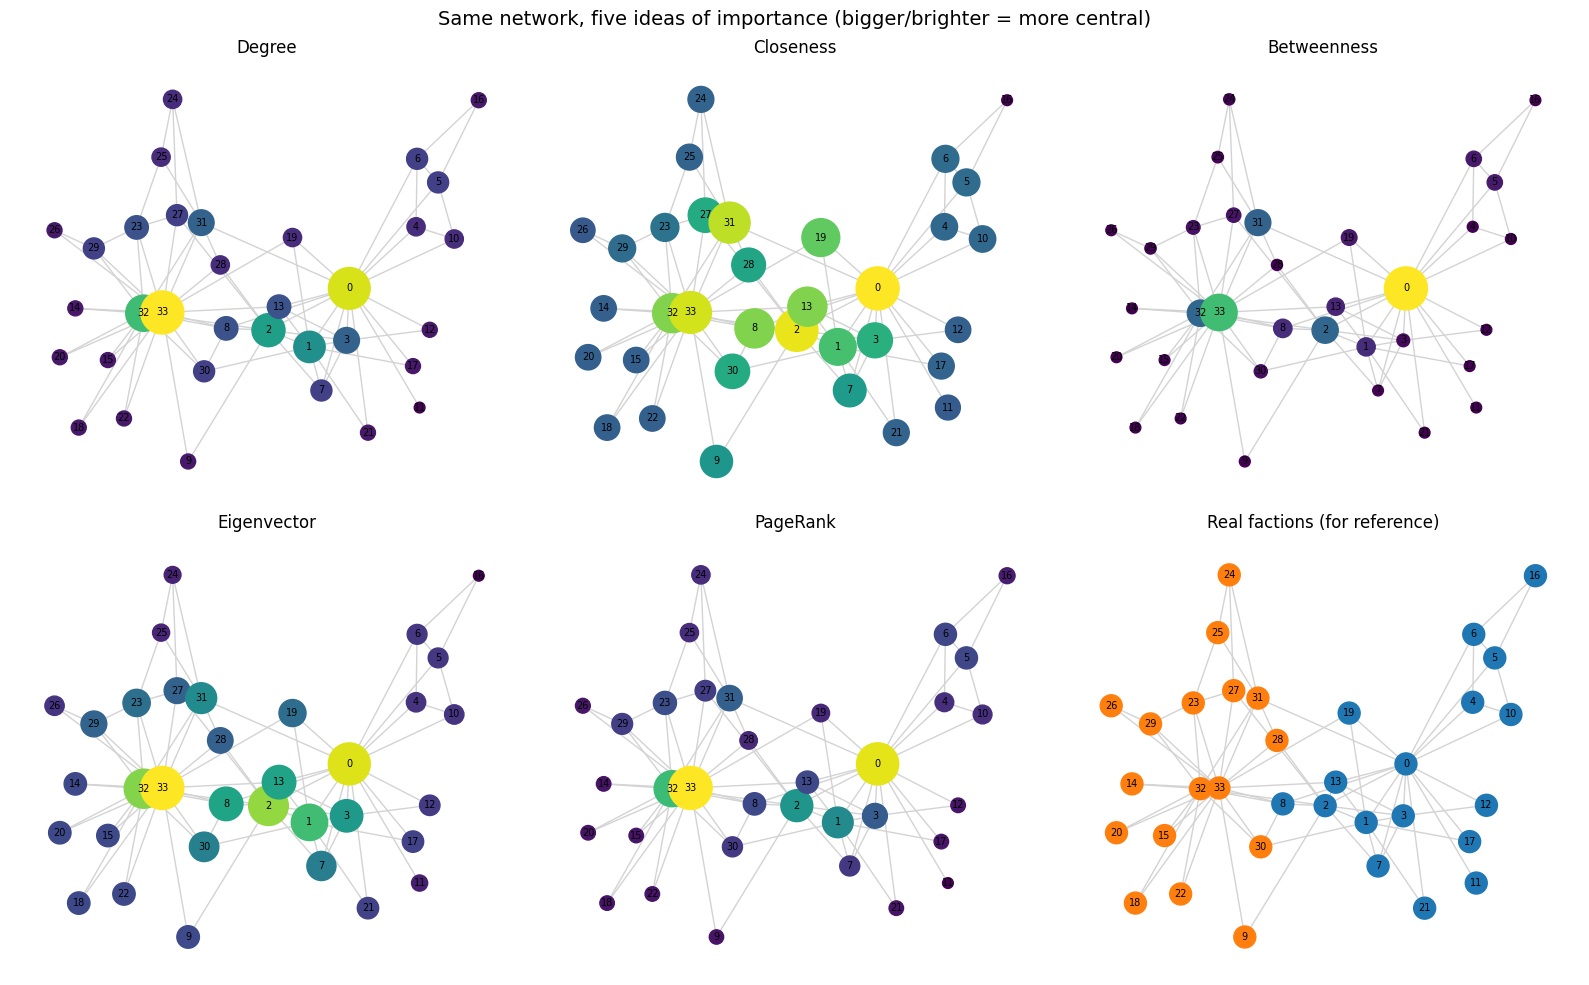

In [11]:
measures = {"Degree": degree_c, "Closeness": closeness_c, "Betweenness": betweenness_c,
            "Eigenvector": eigenvector_c, "PageRank": pagerank_c}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (name, scores) in zip(axes.flat, measures.items()):
    draw_scores(G, scores, ax, name)
# Last panel: the real factions, for reference
nx.draw_networkx(G, pos, node_color=true_colors, node_size=250, font_size=7,
                 edge_color="lightgray", ax=axes.flat[5])
axes.flat[5].set_title("Real factions (for reference)")
axes.flat[5].axis("off")
plt.suptitle("Same network, five ideas of importance (bigger/brighter = more central)", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
centrality_df = pd.DataFrame(measures)
ranks = centrality_df.rank(ascending=False, method="min").astype(int)   # 1 = most central

# Which nodes do the measures disagree about most? (difference between best and worst rank)
ranks["rank_spread"] = ranks.max(axis=1) - ranks.min(axis=1)
print("Ranks (1 = most central) for the leaders and the most disputed nodes:")
display(ranks.loc[[0, 33]])
display(ranks.drop([0, 33]).sort_values("rank_spread", ascending=False).head(5))

Ranks (1 = most central) for the leaders and the most disputed nodes:


,Degree,Closeness,Betweenness,Eigenvector,PageRank,rank_spread
0,2,1,1,2,2,1
33,1,3,2,1,1,2


,Degree,Closeness,Betweenness,Eigenvector,PageRank,rank_spread
9,23,15,20,17,33,18
5,11,17,10,26,12,16
25,17,22,16,31,20,15
6,11,17,11,26,11,15
24,17,22,18,32,19,15


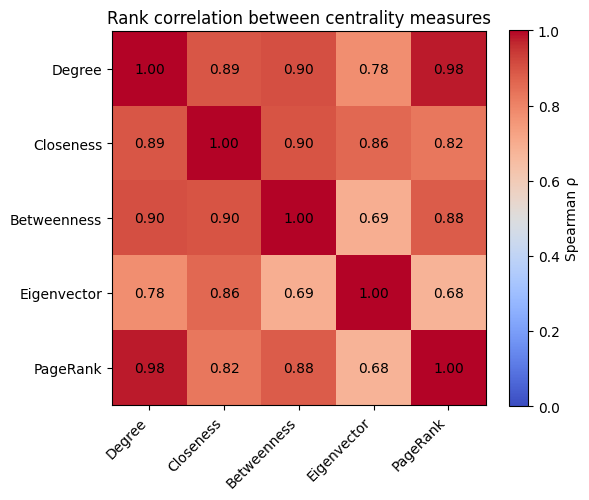

In [13]:
corr = centrality_df.corr(method="spearman")
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=0, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.colorbar(im, label="Spearman ρ")
plt.title("Rank correlation between centrality measures")
plt.tight_layout()
plt.show()

**What the comparison shows**

- **Everyone agrees on the leaders.** Nodes 0 and 33 are in the top 3 under every measure.
- **Degree ≈ PageRank** (ρ ≈ 0.98). In undirected networks PageRank is driven mostly by degree; its advantages show up mainly in directed networks.
- **Eigenvector is the odd one out** (ρ ≈ 0.68 with PageRank, ≈ 0.69 with betweenness). It rewards being *embedded among* well-connected nodes, while betweenness rewards *bridging* between groups.
- **The disputed nodes are the interesting ones** (the `rank_spread` table):
  - **Node 9** has only 2 friends, so it ranks last on PageRank. But those friends are node 2 and the leader node 33, so it is only a few steps from everyone, and it ranks 15th on closeness.
  - **Nodes 5 and 6** belong to a small cluster hanging off the instructor (nodes 4, 5, 6, 10, 16). Their friends are not well connected, so eigenvector centrality ranks them 26th. However, they are the *only* route to node 16, which gives them a moderate betweenness rank (10th–11th).
  - **Nodes 24 and 25** sit in a small peripheral cluster in the Officer group, far from the well-connected core, so eigenvector centrality ranks them near the bottom (31st–32nd).
- **Take-home:** choose the measure that matches your question.

| Question | Measure |
|---|---|
| Who has the most direct contacts? | Degree |
| Who can reach everyone in the fewest steps? | Closeness |
| Who controls flows between groups? | Betweenness |
| Who is connected to other well-connected nodes? | Eigenvector (undirected) / PageRank (any graph) |

---
# Part 2 — Community Detection

## 2.1 What is a community?

Many networks contain **communities**: groups of nodes **densely connected to each other** and **sparsely connected to the rest**. Examples include friend circles, functional modules of proteins, and research fields in citation networks.

**Why detect them?** To reveal hidden organization, to simplify large networks, and to understand spreading (ideas and diseases move fast within communities and slowly between them).

**Challenges**
- There is **no single definition** of a community, so different algorithms formalize the idea differently.
- Finding the best partition is computationally hard (NP-hard for modularity; Brandes et al., 2008), so algorithms use heuristics and may give different answers.

**Key references:** Girvan, M., & Newman, M. E. J. (2002). Community structure in social and biological networks. *PNAS*, 99(12), 7821–7826. · Fortunato, S. (2010). Community detection in graphs. *Physics Reports*, 486(3–5), 75–174.

## 2.2 Modularity: how good is a partition?

Modularity $Q$ compares the edges *inside* communities with the number **expected by chance** in a random network where every node keeps its degree:

$$Q = \sum_{c} \left[ \frac{L_c}{m} - \gamma\left(\frac{K_c}{2m}\right)^2 \right]$$

- $L_c/m$: the share of all edges that fall inside community $c$ (what we observe);
- $(K_c/2m)^2$: the share we would expect by chance, where $K_c$ is the total degree of $c$'s nodes;
- $\gamma$: **resolution** parameter (default 1). Larger values produce more, smaller communities.

$Q \approx 0$ means "no better than random"; values of roughly **0.3–0.7** indicate clear community structure. One caveat, the *resolution limit*: maximizing $Q$ can merge small genuine communities in large networks (Fortunato & Barthélemy, 2007).

**Reference:** Newman, M. E. J., & Girvan, M. (2004). Finding and evaluating community structure in networks. *Physical Review E*, 69(2), 026113.

**`nx_comm.modularity(G, communities, weight='weight', resolution=1)`** takes a list of node sets (each node in exactly one set) and applies the formula above. We check it by hand below.

In [14]:
true_partition = [{v for v in G if club[v] == "Mr. Hi"}, {v for v in G if club[v] == "Officer"}]

def modularity_by_hand(G, communities, gamma=1.0):
    m = G.number_of_edges()
    Q = 0.0
    for c in communities:
        L_c = G.subgraph(c).number_of_edges()     # edges inside community c
        K_c = sum(d for _, d in G.degree(c))      # total degree of c's nodes
        Q += L_c / m - gamma * (K_c / (2 * m)) ** 2
    return Q

print(f"Real faction split: Q = {nx_comm.modularity(G, true_partition, weight=None):.4f} "
      f"(by hand: {modularity_by_hand(G, true_partition):.4f})")

rng = np.random.default_rng(SEED)
random_labels = rng.integers(0, 2, len(G))                       # each node gets group 0 or 1 at random
random_partition = [{v for v in G if random_labels[v] == c} for c in (0, 1)]
print(f"Random split:       Q = {nx_comm.modularity(G, random_partition, weight=None):.4f}")

Real faction split: Q = 0.3582 (by hand: 0.3582)
Random split:       Q = 0.0512


## 2.3 Comparing a detected partition with the truth: NMI and ARI

Modularity tells us whether a partition is *structurally* good. But when we know the real groups, we also want to ask: **how similar is the detected partition to the real one?** Two scores are standard. Both:
- compare **two partitions of the same nodes**;
- give **1 for identical partitions**;
- **ignore community names**. "Group 0 / group 1" versus "group 1 / group 0" is the same partition, which matters because algorithms number communities arbitrarily.

### ARI: Adjusted Rand Index (pair counting)
1. Look at **every pair of nodes**. For each pair, ask two yes/no questions: *Are they in the same group in the true partition? Are they in the same group in the detected one?*
2. If both answers are the same (both "together" or both "apart"), the partitions **agree** on that pair.
3. The **Rand index** is the share of pairs on which they agree.

The problem: most pairs are "apart" in *any* partition, so even a random partition gets a fairly high Rand index. The **adjusted** version subtracts the agreement expected by chance:

$$ARI = \frac{\text{Rand index} - \text{expected Rand index}}{\text{max Rand index} - \text{expected Rand index}}$$

So **ARI = 1** means identical, **ARI ≈ 0** means no better than random (it can even be negative).

### NMI: Normalized Mutual Information (information)
NMI asks: *"If I tell you which detected community a node is in, how much does that tell you about its true community?"*
- **Entropy $H$** measures uncertainty: how hard it is to guess a node's group.
- **Mutual information $I(A;B)$** is how much knowing the group in partition $A$ reduces the uncertainty about the group in $B$.
- Normalizing gives a score between 0 and 1: $NMI = \frac{2\,I(A;B)}{H(A) + H(B)}$.

So **NMI = 1** means knowing one partition tells you the other exactly; **NMI = 0** means it tells you nothing.

**References:** Hubert, L., & Arabie, P. (1985). Comparing partitions. *Journal of Classification*, 2(1), 193–218. · Danon, L., Díaz-Guilera, A., Duch, J., & Arenas, A. (2005). Comparing community structure identification. *J. Statistical Mechanics*, P09008.

### A tiny example to build intuition
Six nodes, truth = two groups of three: $\{a,b,c\}$ and $\{d,e,f\}$. Partitions are written as **label lists** (one label per node), which is what `sklearn.metrics.adjusted_rand_score(true, pred)`, `normalized_mutual_info_score(true, pred)` and `rand_score(true, pred)` expect.

In [15]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, rand_score

truth = [0, 0, 0, 1, 1, 1]                     # nodes a b c | d e f
examples = {
    "identical, labels renamed":   [1, 1, 1, 0, 0, 0],
    "one node misplaced":          [0, 0, 1, 1, 1, 1],
    "each group split in two":     [0, 0, 1, 2, 2, 3],
    "everything in one group":     [0, 0, 0, 0, 0, 0],
    "every node alone":            [0, 1, 2, 3, 4, 5],
}
toy = pd.DataFrame({
    name: {"Rand index": rand_score(truth, pred),
           "ARI": adjusted_rand_score(truth, pred),
           "NMI": normalized_mutual_info_score(truth, pred)}
    for name, pred in examples.items()
}).T.round(3)
display(toy)

,Rand index,ARI,NMI
"identical, labels renamed",1.000,1.000,1.000
one node misplaced,0.667,0.324,0.479
each group split in two,0.733,0.375,0.685
everything in one group,0.400,0.000,0.000
every node alone,0.600,0.000,0.558


**Reading the table**
- **Renamed labels** score 1 on everything: names don't matter, only the grouping.
- **"Every node alone"** still gets a Rand index of 0.6: all the "apart" pairs agree by default. This is why we use the *adjusted* version; ARI correctly gives 0.
- **NMI is more forgiving of over-splitting** than ARI. When the true groups are cut into pieces, NMI stays fairly high (knowing a small piece still tells you the true group), while ARI drops more. Even "every node alone" gets a non-zero NMI.
- **Practical advice:** report **both**. ARI is stricter about the number of groups; NMI rewards partitions that don't *mix* the true groups.

Next, two helpers used for every algorithm: one converts a list of node sets into a label list, and one computes all the scores.

In [16]:
def to_labels(G, communities):
    '''List of node sets -> list with one community label per node (in G.nodes() order).'''
    label = {v: i for i, c in enumerate(communities) for v in c}
    return [label[v] for v in G]

true_labels = to_labels(G, true_partition)

def evaluate(communities, name):
    labels = to_labels(G, communities)
    return {"algorithm": name, "n_communities": len(communities),
            "modularity": round(nx_comm.modularity(G, communities, weight=None), 3),
            "ARI_vs_truth": round(adjusted_rand_score(true_labels, labels), 3),
            "NMI_vs_truth": round(normalized_mutual_info_score(true_labels, labels), 3)}

partitions = {"Ground truth": true_partition}   # we will store every algorithm's result here

## 2.4 Greedy Modularity Maximization (Clauset–Newman–Moore)

A **bottom-up** method:
1. Start with every node in its own community.
2. Merge the pair of connected communities that **increases $Q$ the most**.
3. Repeat until no merge increases $Q$.

The CNM version is fast because it keeps the possible gains in a priority queue. Its weakness is that merges are never undone, and it tends to produce a few large communities.

**References:** Newman, M. E. J. (2004). Fast algorithm for detecting community structure in networks. *Physical Review E*, 69(6), 066133. · Clauset, A., Newman, M. E. J., & Moore, C. (2004). Finding community structure in very large networks. *Physical Review E*, 70(6), 066111.

**`nx_comm.greedy_modularity_communities(G, weight=None, resolution=1, best_n=None)`** returns a list of node sets, largest first. `best_n` can force a maximum number of communities.

In [17]:
partitions["Greedy (CNM)"] = [set(c) for c in nx_comm.greedy_modularity_communities(G, weight=None)]
for i, c in enumerate(partitions["Greedy (CNM)"]):
    print(f"Community {i} ({len(c)} nodes): {sorted(c)}")

Community 0 (17 nodes): [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Community 1 (9 nodes): [1, 2, 3, 7, 9, 12, 13, 17, 21]
Community 2 (8 nodes): [0, 4, 5, 6, 10, 11, 16, 19]


## 2.5 Louvain Algorithm

The most widely used method thanks to its speed. It repeats two phases:
1. **Local moving:** each node, in random order, moves to the neighbouring community that increases $Q$ the most. Repeat until no move helps.
2. **Aggregation:** collapse each community into a single "super-node" and run phase 1 again on this smaller network.

It stops when $Q$ no longer increases. It runs in roughly linear time, so it handles millions of edges. The random node order means results can differ between runs, so use a `seed`.

**Reference:** Blondel, V. D., Guillaume, J.-L., Lambiotte, R., & Lefebvre, E. (2008). Fast unfolding of communities in large networks. *J. Statistical Mechanics*, P10008.

**`nx_comm.louvain_communities(G, weight='weight', resolution=1, seed=None)`**
- `weight`: **defaults to `'weight'`**; we pass `None`.
- `resolution`: $\gamma$ from Section 2.2.
- `seed`: fixes the random order.

In [18]:
partitions["Louvain"] = nx_comm.louvain_communities(G, weight=None, seed=SEED)
for i, c in enumerate(partitions["Louvain"]):
    print(f"Community {i} ({len(c)} nodes): {sorted(c)}")

Community 0 (5 nodes): [4, 5, 6, 10, 16]
Community 1 (11 nodes): [0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21]
Community 2 (6 nodes): [23, 24, 25, 27, 28, 31]
Community 3 (12 nodes): [8, 9, 14, 15, 18, 20, 22, 26, 29, 30, 32, 33]


**Comparison: how the resolution parameter and the random seed change the result.**

In [19]:
rows = []
for gamma in [0.5, 1.0, 1.5, 2.0]:
    comms = nx_comm.louvain_communities(G, weight=None, resolution=gamma, seed=SEED)
    rows.append({"resolution γ": gamma, "n_communities": len(comms),
                 "modularity (γ=1)": round(nx_comm.modularity(G, comms, weight=None), 3)})
display(pd.DataFrame(rows))

print("Number of communities by seed:",
      {s: len(nx_comm.louvain_communities(G, weight=None, seed=s)) for s in [SEED, 0, 1, 2, 3, 4]})

,resolution γ,n_communities,modularity (γ=1)
0,0.5,2,0.372
1,1.0,4,0.420
2,1.5,5,0.406
3,2.0,8,0.325


Number of communities by seed: {19880106: 4, 0: 4, 1: 4, 2: 4, 3: 4, 4: 4}


## 2.6 Leiden Algorithm

Traag et al. (2019) showed that Louvain can produce **badly connected or even disconnected communities**: a "community" whose members can't reach each other inside it. Leiden adds a **refinement** step between moving and aggregation. Each community is checked and, if needed, split into well-connected parts before it is collapsed. The result: **every community is guaranteed to be connected**, and Leiden usually reaches equal or higher modularity, often faster.

**Reference:** Traag, V. A., Waltman, L., & van Eck, N. J. (2019). From Louvain to Leiden: guaranteeing well-connected communities. *Scientific Reports*, 9, 5233.

networkx has no pure-Python Leiden, so we use the reference implementation `leidenalg` (by Traag), which works on **igraph** graphs:
- **`ig.Graph.from_networkx(G)`** converts the graph. igraph numbers nodes 0..n−1 and keeps the original name in `"_nx_name"`.
- **`leidenalg.find_partition(graph, leidenalg.ModularityVertexPartition, seed=..., n_iterations=-1)`** optimizes modularity; `n_iterations=-1` runs until there is no further improvement. Iterating over the result gives lists of node indices.

In [20]:
try:
    import igraph as ig
    import leidenalg
    G_ig = ig.Graph.from_networkx(G)
    part = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition, seed=SEED, n_iterations=-1)
    names = G_ig.vs["_nx_name"]                                    # map igraph indices back to our node names
    partitions["Leiden"] = [set(names[i] for i in comm) for comm in part]
    for i, c in enumerate(partitions["Leiden"]):
        print(f"Community {i} ({len(c)} nodes): {sorted(c)}")
except ImportError:
    print("igraph/leidenalg not installed -> pip install python-igraph leidenalg (section skipped)")

# Louvain vs Leiden: are all communities internally connected?
for name in ["Louvain", "Leiden"]:
    if name in partitions:
        print(f"{name}: all communities connected? "
              f"{all(nx.is_connected(G.subgraph(c)) for c in partitions[name])}")

Community 0 (12 nodes): [8, 9, 14, 15, 18, 20, 22, 26, 29, 30, 32, 33]
Community 1 (11 nodes): [0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21]
Community 2 (6 nodes): [23, 24, 25, 27, 28, 31]
Community 3 (5 nodes): [4, 5, 6, 10, 16]
Louvain: all communities connected? True
Leiden: all communities connected? True


On a small, tidy network like the karate club, Louvain's communities happen to be connected too. Leiden's guarantee matters most on large, messy networks, where Traag et al. found many badly connected Louvain communities.

## 2.7 Label Propagation

A very different idea: **no objective function**, just local "peer pressure".
1. Give every node a unique label.
2. In random order, each node adopts the **label most common among its neighbours** (ties broken at random).
3. Stop when every node already has its neighbourhood's most common label.

Dense groups quickly agree on one label, and labels struggle to cross sparse boundaries. It is extremely fast and needs no parameters, but results vary from run to run.

**Reference:** Raghavan, U. N., Albert, R., & Kumara, S. (2007). Near linear time algorithm to detect community structures in large-scale networks. *Physical Review E*, 76(3), 036106.

**`nx_comm.asyn_lpa_communities(G, weight=None, seed=None)`**: the original asynchronous version (nodes update one at a time). It returns a generator, so we wrap it in a list.

In [21]:
partitions["Label propagation"] = [set(c) for c in nx_comm.asyn_lpa_communities(G, seed=SEED)]
for i, c in enumerate(partitions["Label propagation"]):
    print(f"Community {i} ({len(c)} nodes): {sorted(c)}")
print("\nNumber of communities with seeds 0–4:",
      [len(list(nx_comm.asyn_lpa_communities(G, seed=s))) for s in range(5)])

Community 0 (13 nodes): [0, 1, 2, 3, 7, 8, 11, 12, 13, 17, 19, 21, 30]
Community 1 (2 nodes): [4, 10]
Community 2 (3 nodes): [5, 6, 16]
Community 3 (12 nodes): [9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 32, 33]
Community 4 (4 nodes): [24, 25, 28, 31]

Number of communities with seeds 0–4: [3, 3, 2, 2, 3]


## 2.8 Comparing the Algorithms

We now compare all algorithms visually and with the scores from Sections 2.2–2.3.

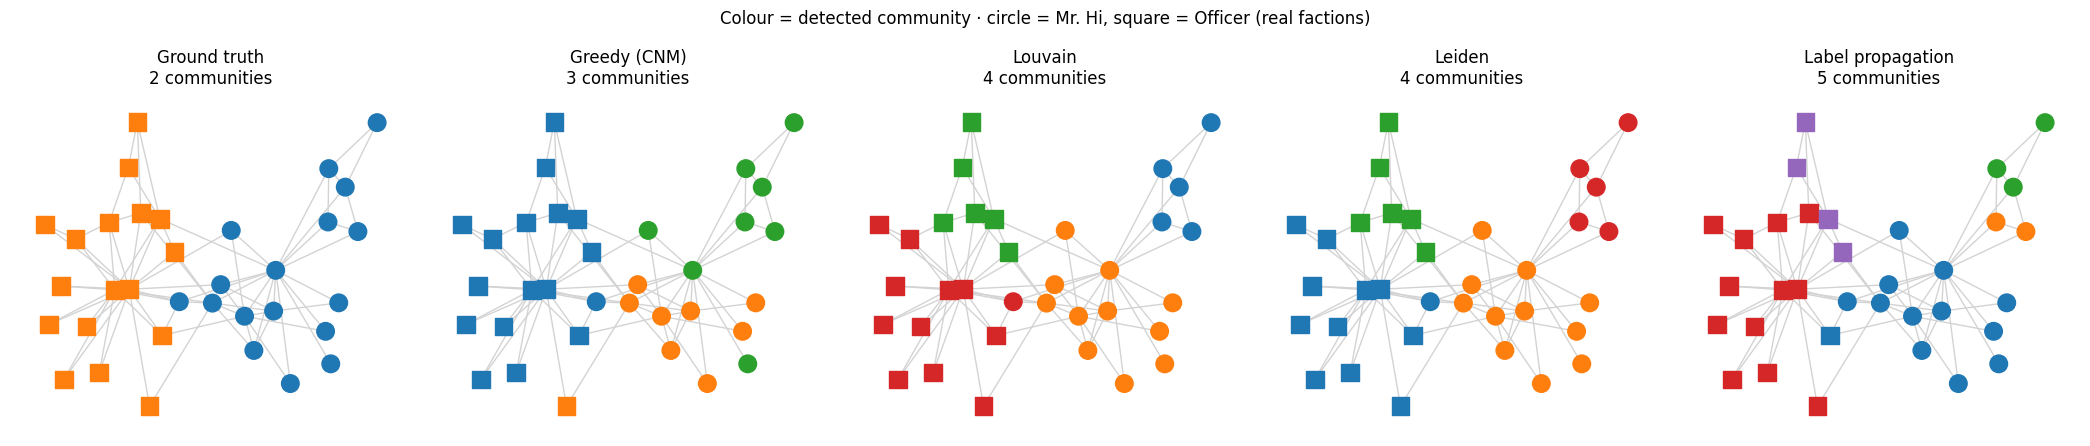

,n_communities,modularity,ARI_vs_truth,NMI_vs_truth
algorithm,,,,
Ground truth,2,0.358,1.000,1.000
Greedy (CNM),3,0.381,0.568,0.565
Louvain,4,0.420,0.465,0.588
Leiden,4,0.420,0.465,0.588
Label propagation,5,0.379,0.487,0.572


In [22]:
fig, axes = plt.subplots(1, len(partitions), figsize=(4.2 * len(partitions), 4.5))
for ax, (name, comms) in zip(axes, partitions.items()):
    labels = to_labels(G, comms)
    nx.draw_networkx_edges(G, pos, edge_color="lightgray", ax=ax)
    for faction, shape in [("Mr. Hi", "o"), ("Officer", "s")]:
        nodes = [v for v in G if club[v] == faction]
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_shape=shape, node_size=160,
                               node_color=[plt.cm.tab10(labels[v] % 10) for v in nodes], ax=ax)
    ax.set_title(f"{name}\n{len(comms)} communities")
    ax.axis("off")
plt.suptitle("Colour = detected community · circle = Mr. Hi, square = Officer (real factions)")
plt.tight_layout()
plt.show()

results_df = pd.DataFrame([evaluate(c, name) for name, c in partitions.items()]).set_index("algorithm")
display(results_df)

**What the comparison shows**

- **Higher modularity than the truth.** Every modularity-based algorithm finds a partition with *higher* $Q$ than the real two-faction split. It cuts the network into 3–4 groups, splitting the factions into sub-groups. So "best modularity" and "real-world groups" are **not the same thing**; the real split is only one meaningful view of the network (Peel, Larremore & Clauset, 2017).
- **No community mixes the factions much.** Look at the shapes: most detected communities contain mostly circles or mostly squares. The algorithms split the factions but rarely merge across them. This is why NMI stays moderate while ARI (which penalizes the extra groups) varies more.
- **The highest modularity doesn't guarantee the closest match to the truth.** Leiden has the highest $Q$ but a lower ARI than Louvain. Its NMI is slightly *higher*, though: Leiden cuts the factions into more, but cleaner, pieces. NMI tolerates this, while ARI penalizes the extra groups (as in the toy example in 2.3).
- **Randomness matters.** Louvain and label propagation change with the seed, so in practice run them several times and check stability.
- **Resolution is a knob.** With $\gamma = 0.5$, Louvain finds 2 communities with ARI ≈ 0.77 against the truth, a closer match than any algorithm at the default $\gamma = 1$. If you know roughly how many groups to expect, tuning $\gamma$ can matter more than choosing the algorithm.

## 2.9 Bringing it together: centrality × communities

Once we have communities, we can ask a sharper question about each node: **is it important *inside* its community, or does it *connect* communities?** Guimerà & Amaral (2005) proposed two scores:

- **Within-module degree z-score** $z_i$: how many links node $i$ has *inside its own community*, compared with the average member of that community (in standard deviations). High $z$ = a **local hub**.
- **Participation coefficient** $P_i = 1 - \sum_c \left(\frac{k_{i,c}}{k_i}\right)^2$, where $k_{i,c}$ is the number of $i$'s links going to community $c$.
  - All links in one community → $P = 0$.
  - Links spread evenly over several communities → $P$ approaches 1. High $P$ = a **connector**.
  - Example: a node with 4 links, 2 into each of two communities, has $P = 1 - (0.5^2 + 0.5^2) = 0.5$.

We use the Louvain partition, then compare these roles with **betweenness** from Part 1, because connectors should also be brokers.

**Reference:** Guimerà, R., & Amaral, L. A. N. (2005). Functional cartography of complex metabolic networks. *Nature*, 433(7028), 895–900.

In [23]:
from collections import Counter

node_comm = dict(zip(G, to_labels(G, partitions["Louvain"])))

# Participation coefficient
P = {}
for i in G:
    links_per_comm = Counter(node_comm[j] for j in G.neighbors(i))      # k_ic for each community c
    P[i] = 1 - sum((k_ic / G.degree(i)) ** 2 for k_ic in links_per_comm.values())

# Within-module degree z-score
k_own = {i: sum(node_comm[j] == node_comm[i] for j in G.neighbors(i)) for i in G}   # links inside own community
z = {}
for c in set(node_comm.values()):
    members = [i for i in G if node_comm[i] == c]
    vals = np.array([k_own[i] for i in members])
    for i in members:
        z[i] = (k_own[i] - vals.mean()) / vals.std() if vals.std() > 0 else 0.0

roles = pd.DataFrame({"community": node_comm, "degree": dict(G.degree()), "P": P, "z": z,
                      "betweenness": betweenness_c}).round(3)
print("Spearman correlation, P vs betweenness:", round(spearmanr(roles["P"], roles["betweenness"])[0], 3))
print("Nodes with P = 0 (all links inside own community):", (roles["P"] == 0).sum(), "of", len(G))
display(roles.sort_values("betweenness", ascending=False).head(8))

Spearman correlation, P vs betweenness: 0.734
Nodes with P = 0 (all links inside own community): 15 of 34


,community,degree,P,z,betweenness
0,1,16,0.539,2.136,0.438
33,3,17,0.512,2.512,0.304
32,3,12,0.403,1.842,0.145
2,1,10,0.620,0.300,0.144
31,2,6,0.611,0.894,0.138
8,3,5,0.480,-0.167,0.056
1,1,9,0.198,1.402,0.054
13,1,5,0.320,-0.067,0.046


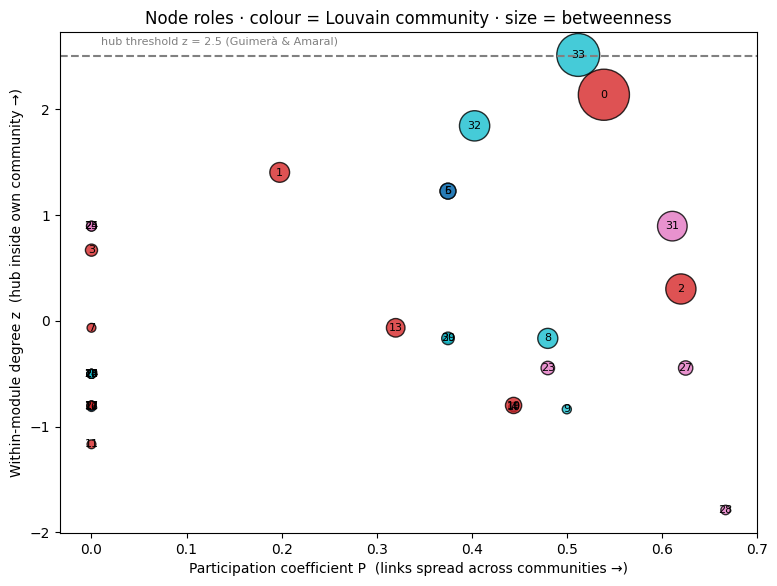

In [24]:
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(roles["P"], roles["z"], c=roles["community"], cmap="tab10",
           s=3000 * roles["betweenness"] + 40, edgecolors="black", alpha=0.8)
for v, row in roles.iterrows():
    ax.annotate(v, (row["P"], row["z"]), fontsize=8, ha="center", va="center")
ax.axhline(2.5, ls="--", c="gray")
ax.text(0.01, 2.6, "hub threshold z = 2.5 (Guimerà & Amaral)", color="gray", fontsize=8)
ax.set_xlabel("Participation coefficient P  (links spread across communities →)")
ax.set_ylabel("Within-module degree z  (hub inside own community →)")
ax.set_title("Node roles · colour = Louvain community · size = betweenness")
plt.show()

**How to read the plot**

The two axes separate two different kinds of importance. **Up** means a node is a big player *inside* its own community. **Right** means a node's links are spread *across* communities.

- **The two leaders are hubs, but different kinds.** Both nodes 0 and 33 are above the hub line.
  - **Node 0** (z ≈ 3.2, P ≈ 0.23) is a *provincial hub*: most of its links stay inside its own community.
  - **Node 33** (z ≈ 2.6, P ≈ 0.46) is a *connector hub*: it also reaches into other communities.

  Degree centrality ranked them almost equally; this plot shows they play different roles.
- **Nodes 2 and 31 are the brokers** (P ≈ 0.54 and 0.61). They are not hubs, but their links spread across communities, and they have the highest betweenness after the two leaders and node 32. Node 2 is also the member with the most friends in the *other* faction (4).
- **High P does not always mean high betweenness.** Nodes 28, 27 and 9 have high P but almost zero betweenness. With only 2–4 links, having one or two in another community already gives a high P. **P measures how *diverse* a node's links are; betweenness measures how much *traffic* flows through it.** Both scores are needed, which explains why their correlation is moderate (ρ ≈ 0.66) rather than near 1.
- **About half the network (18 of 34 nodes) has P = 0** (bottom-left). These are peripheral members whose friends are all in their own community, and nearly all of them have zero betweenness.

**Take-home:** communities give centrality a context. Instead of asking only "how central is this node?", we can ask "central *where*: inside its group, or between groups?"

---
# Part 3 — Summary, Exercises, and References

## 3.1 Summary

| Centrality | Idea | networkx |
|---|---|---|
| Degree | number of direct ties | `degree_centrality` |
| Closeness | inverse of the average shortest-path distance | `closeness_centrality` |
| Betweenness | share of shortest paths through the node | `betweenness_centrality` |
| Eigenvector | connected to important nodes | `eigenvector_centrality` |
| PageRank | random surfer with random jumps | `pagerank` |

| Community detection | Approach | Function |
|---|---|---|
| Greedy (CNM) | merge communities bottom-up to maximize $Q$ | `greedy_modularity_communities` |
| Louvain | local moving + aggregation | `louvain_communities` |
| Leiden | Louvain + refinement (connected communities) | `leidenalg.find_partition` |
| Label propagation | adopt neighbours' most common label | `asyn_lpa_communities` |

**Evaluation:** modularity $Q$ (structure), ARI and NMI (agreement with a known partition).

**Practical tips:** check whether your graph is directed, weighted or disconnected; watch out for `weight='weight'` defaults in `pagerank` and `louvain_communities`; fix and vary seeds for randomized algorithms.

## 3.2 Exercises

1. **Weights.** Recompute degree, PageRank and Louvain using the edge weights (`weight="weight"`). What changes?
2. **Robustness.** Remove the top-3 nodes by degree, then (separately) by betweenness. Which removal breaks the network into more pieces? (Hint: `nx.number_connected_components`.)
3. **Bigger network.** Repeat the comparisons on `nx.les_miserables_graph()` (character co-appearances in *Les Misérables*; Knuth, 1993).
4. **NMI vs. ARI.** Run Louvain with resolution 0.5, 1, 2 and 3 on the karate club. Plot NMI and ARI against the number of communities. Which score drops faster, and why?

## 3.3 References

- Bavelas, A. (1950). Communication patterns in task-oriented groups. *Journal of the Acoustical Society of America*, 22(6), 725–730.
- Blondel, V. D., Guillaume, J.-L., Lambiotte, R., & Lefebvre, E. (2008). Fast unfolding of communities in large networks. *Journal of Statistical Mechanics*, P10008.
- Bonacich, P. (1972). Factoring and weighting approaches to status scores and clique identification. *Journal of Mathematical Sociology*, 2(1), 113–120.
- Bonacich, P. (1987). Power and centrality: A family of measures. *American Journal of Sociology*, 92(5), 1170–1182.
- Borgatti, S. P. (2005). Centrality and network flow. *Social Networks*, 27(1), 55–71.
- Brandes, U. (2001). A faster algorithm for betweenness centrality. *Journal of Mathematical Sociology*, 25(2), 163–177.
- Brandes, U., Delling, D., Gaertler, M., Görke, R., Hoefer, M., Nikoloski, Z., & Wagner, D. (2008). On modularity clustering. *IEEE Transactions on Knowledge and Data Engineering*, 20(2), 172–188.
- Brin, S., & Page, L. (1998). The anatomy of a large-scale hypertextual Web search engine. *Computer Networks and ISDN Systems*, 30(1–7), 107–117.
- Clauset, A., Newman, M. E. J., & Moore, C. (2004). Finding community structure in very large networks. *Physical Review E*, 70(6), 066111.
- Danon, L., Díaz-Guilera, A., Duch, J., & Arenas, A. (2005). Comparing community structure identification. *Journal of Statistical Mechanics*, P09008.
- Fortunato, S. (2010). Community detection in graphs. *Physics Reports*, 486(3–5), 75–174.
- Fortunato, S., & Barthélemy, M. (2007). Resolution limit in community detection. *PNAS*, 104(1), 36–41.
- Freeman, L. C. (1977). A set of measures of centrality based on betweenness. *Sociometry*, 40(1), 35–41.
- Freeman, L. C. (1978). Centrality in social networks: Conceptual clarification. *Social Networks*, 1(3), 215–239.
- Fruchterman, T. M. J., & Reingold, E. M. (1991). Graph drawing by force-directed placement. *Software: Practice and Experience*, 21(11), 1129–1164.
- Girvan, M., & Newman, M. E. J. (2002). Community structure in social and biological networks. *PNAS*, 99(12), 7821–7826.
- Guimerà, R., & Amaral, L. A. N. (2005). Functional cartography of complex metabolic networks. *Nature*, 433(7028), 895–900.
- Hagberg, A. A., Schult, D. A., & Swart, P. J. (2008). Exploring network structure, dynamics, and function using NetworkX. *Proceedings of the 7th Python in Science Conference*, 11–15.
- Hubert, L., & Arabie, P. (1985). Comparing partitions. *Journal of Classification*, 2(1), 193–218.
- Knuth, D. E. (1993). *The Stanford GraphBase: A Platform for Combinatorial Computing*. Addison-Wesley.
- Newman, M. E. J. (2004). Fast algorithm for detecting community structure in networks. *Physical Review E*, 69(6), 066133.
- Newman, M. E. J., & Girvan, M. (2004). Finding and evaluating community structure in networks. *Physical Review E*, 69(2), 026113.
- Peel, L., Larremore, D. B., & Clauset, A. (2017). The ground truth about metadata and community detection in networks. *Science Advances*, 3(5), e1602548.
- Raghavan, U. N., Albert, R., & Kumara, S. (2007). Near linear time algorithm to detect community structures in large-scale networks. *Physical Review E*, 76(3), 036106.
- Sabidussi, G. (1966). The centrality index of a graph. *Psychometrika*, 31(4), 581–603.
- Traag, V. A., Waltman, L., & van Eck, N. J. (2019). From Louvain to Leiden: guaranteeing well-connected communities. *Scientific Reports*, 9, 5233.
- Valente, T. W., Coronges, K., Lakon, C., & Costenbader, E. (2008). How correlated are network centrality measures? *Connections*, 28(1), 16–26.
- Zachary, W. W. (1977). An information flow model for conflict and fission in small groups. *Journal of Anthropological Research*, 33(4), 452–473.